# TDA — Amsterdam Centre (canal network) vs Eindhoven North (peri-urban)
Improved visualisations with per-figure interpretation annotations.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import rasterio
import gudhi
import matplotlib.patches as mpatches
import scipy.ndimage as ndimage
from scipy.spatial import cKDTree
from skimage.measure import regionprops
from utils import plot_data_binary, plot_topological_grids

from utils import load_tif, plot_topological_grids, plot_data_binary

CITIES = ["Amsterdam Centre", "Eindhoven North"]
PATHS  = {"Amsterdam Centre": "data/amsterdam_centre_strip.tif",
           "Eindhoven North":  "data/eindhoven_north_strip.tif"}

### Data Loading
Ensure the `.tif` files are available in the specified directory.

In [2]:
print("Loading data …")
try:
    data = {c: load_tif(PATHS[c]) for c in CITIES}
    ams, ehv = data["Amsterdam Centre"], data["Eindhoven North"]
    print(f"  Amsterdam  shape={ams.shape}  range=[{np.nanmin(ams):.2f}, {np.nanmax(ams):.2f}] m")
    print(f"  Eindhoven  shape={ehv.shape}  range=[{np.nanmin(ehv):.2f}, {np.nanmax(ehv):.2f}] m")
except Exception as e:
    print(f"Error: {e}. Please ensure data files exist in the /data folder.")

Loading data …
  Amsterdam  shape=(25000, 10000)  range=[-10.02, 16.53] m
  Eindhoven  shape=(12500, 20000)  range=[10.40, 35.04] m


### Step 0 — Dataset Statistics

In [ ]:
print("=" * 70)
print("DATASET STRUCTURE & STATISTICS")
print("=" * 70)

for name in CITIES:
    d = data[name]
    v = d[~np.isnan(d)]
    
    print(f"\n{name.upper()}")
    print("-" * 70)
    print(f"  Shape (rows, cols):        {d.shape}")
    print(f"  Data type:                 {d.dtype}")
    print(f"  Total pixels:              {d.size:,}")
    print(f"  Missing values (NaN):      {np.isnan(d).sum():,} ({100*np.isnan(d).sum()/d.size:.2f}%)")
    print(f"  Valid data points:         {v.size:,}")
    print(f"\n  Elevation Statistics:")
    print(f"    Min:                     {np.min(v):.3f} m")
    print(f"    Max:                     {np.max(v):.3f} m")
    print(f"    Range:                   {np.max(v) - np.min(v):.3f} m")
    print(f"    Mean:                    {np.mean(v):.3f} m")
    print(f"    Median:                  {np.median(v):.3f} m")
    print(f"    Std Dev:                 {np.std(v):.3f} m")
    print(f"    25th percentile:         {np.percentile(v, 25):.3f} m")
    print(f"    75th percentile:         {np.percentile(v, 75):.3f} m")
    print(f"    IQR:                     {np.percentile(v, 75) - np.percentile(v, 25):.3f} m")
    
    # Local variation analysis
    grad = np.gradient(d)
    slope = np.sqrt(grad[0]**2 + grad[1]**2)
    print(f"\n  Slope Statistics (local variation):")
    print(f"    Mean slope:              {np.nanmean(slope):.4f} m/pixel")
    print(f"    Max slope:               {np.nanmax(slope):.4f} m/pixel")
    print(f"    Std slope:               {np.nanstd(slope):.4f} m/pixel")

DATASET STRUCTURE & STATISTICS

AMSTERDAM CENTRE
----------------------------------------------------------------------
  Shape (rows, cols):        (25000, 10000)
  Data type:                 float64
  Total pixels:              250,000,000
  Missing values (NaN):      99,083,748 (39.63%)
  Valid data points:         150,916,252

  Elevation Statistics:
    Min:                     -10.020 m
    Max:                     16.533 m
    Range:                   26.552 m
    Mean:                    -0.173 m
    Median:                  -0.038 m
    Std Dev:                 2.148 m
    25th percentile:         -1.581 m
    75th percentile:         0.952 m
    IQR:                     2.533 m

  Slope Statistics (local variation):
    Mean slope:              0.0377 m/pixel
    Max slope:               8.4064 m/pixel
    Std slope:               0.0657 m/pixel

EINDHOVEN NORTH
----------------------------------------------------------------------
  Shape (rows, cols):        (12500, 20000)


### Missing Data Visualization


[SUCCESS] Saved unified column visualization to: output/combined_missing_data_mask.png



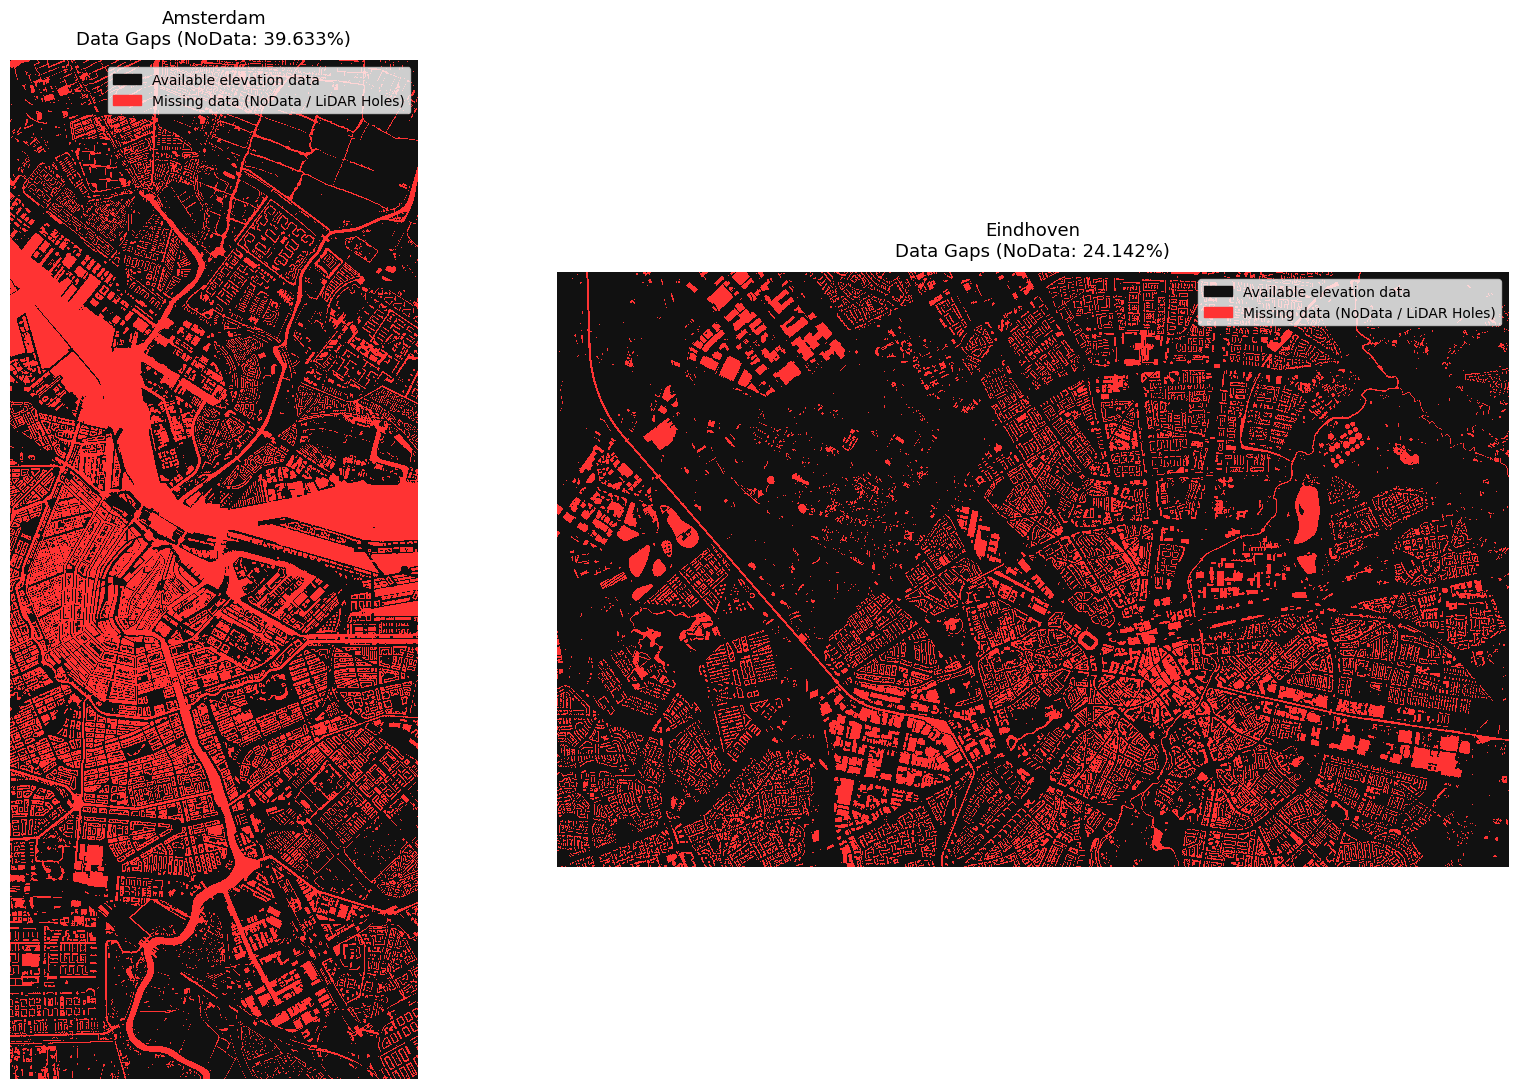

In [6]:
raw_data_dict = {
    "Amsterdam": ams,
    "Eindhoven": ehv
}
plot_data_binary(raw_data_dict, list(raw_data_dict.keys()))

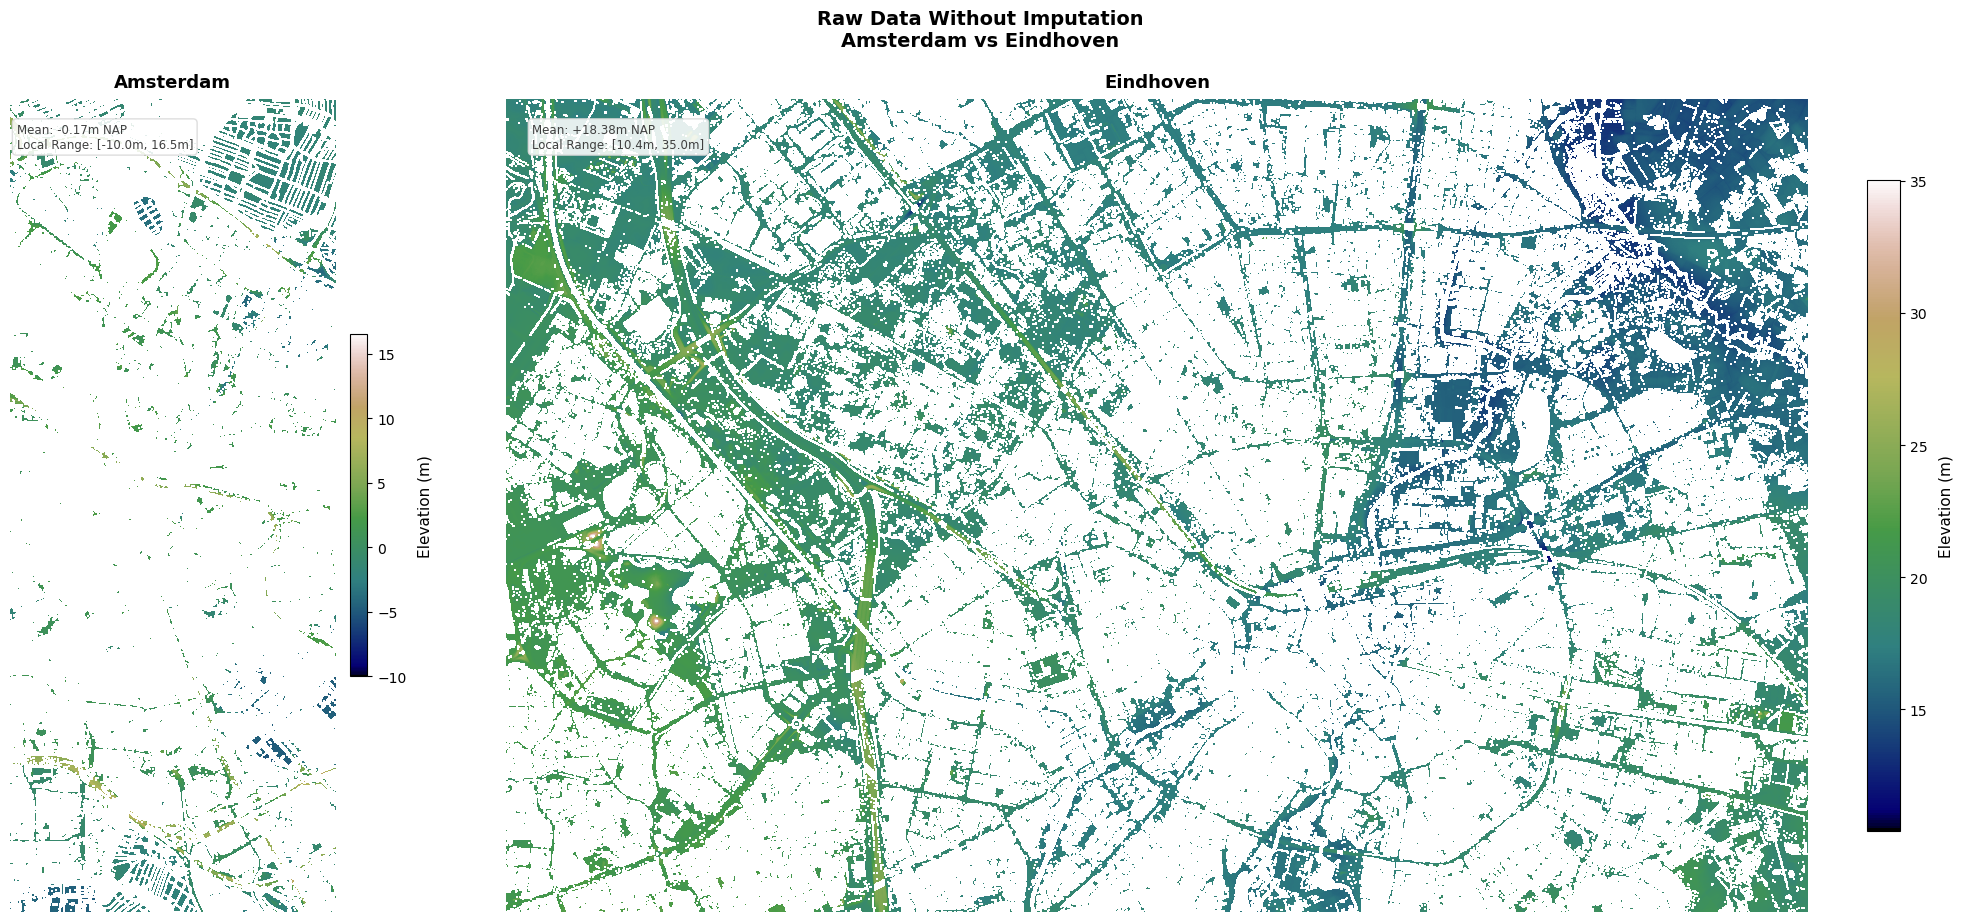

In [ ]:
plot_topological_grids(raw_data_dict, step_title="Raw Data Without Imputation", cmap_name="gist_earth")

## Missing data observations - Amsterdam
- almost 40% missing data
- mostly missing canals and water
- many areas where only few pixels are available

## Imputation plan
- Step 1 — Micro-Inpainting
Fills small sparse holes across roofs and terrain using local interpolation, reducing early topological noise.

- Step 2 — Quay Wall Isolation
Detects low-lying stone borders at the water edge to define a strict structural boundary for the canal network.

- Step 3 — Canal Flood-Fill
Uses connected-component propagation to fill only contiguous canal regions, fixing canal beds at a geodetically accurate level of $-3.0$m NAP.

- Step 4 — Patch-Based IDW
Interpolates remaining large building-footprint gaps in memory-safe $1000 \times 1000$ tiles using only land elevations, preventing canals from bleeding into street terrain.

### Step 1: Morphological Inpainting of Small Voids
Small local gaps (e.g., roofs, shadows, sparse sensor noise) were filled using localized interpolation on the raw elevation matrix (`ams_step1`).

**Topological goal:** remove micro-scale artifacts that would otherwise create many short-lived artificial connected components ($H_0$ noise) in persistence diagrams.

---

In [ ]:
# Initialize our working matrix from your loaded 'ams' data
ams_step1 = ams.copy()
nan_mask = np.isnan(ams_step1)

# 1. Isolate the small architectural roof gaps by labeling all NaN components
labeled_masks, num_features = ndimage.label(nan_mask)
feature_sizes = ndimage.sum(nan_mask, labeled_masks, range(1, num_features + 1))

# Define roof holes as anything smaller than 500 pixels (massive holes are canals)
HOLE_THRESHOLD = 500
small_hole_indices = np.where(feature_sizes <= HOLE_THRESHOLD)[0] + 1
roof_gaps_mask = np.isin(labeled_masks, small_hole_indices)

# 2. Localized spatial interpolation to patch the roof gaps
indices = ndimage.distance_transform_edt(
    nan_mask, 
    return_distances=False, 
    return_indices=True
)
interpolated_full = ams_step1[tuple(indices)]

# Impute ONLY the roof gaps, leaving large canal voids untouched
ams_step1[roof_gaps_mask] = interpolated_full[roof_gaps_mask]
print(f"Step 1 Complete: Imputed {np.sum(roof_gaps_mask):,} architectural roof pixels.")

Step 1 Complete: Imputed 7,010,437 architectural roof pixels.


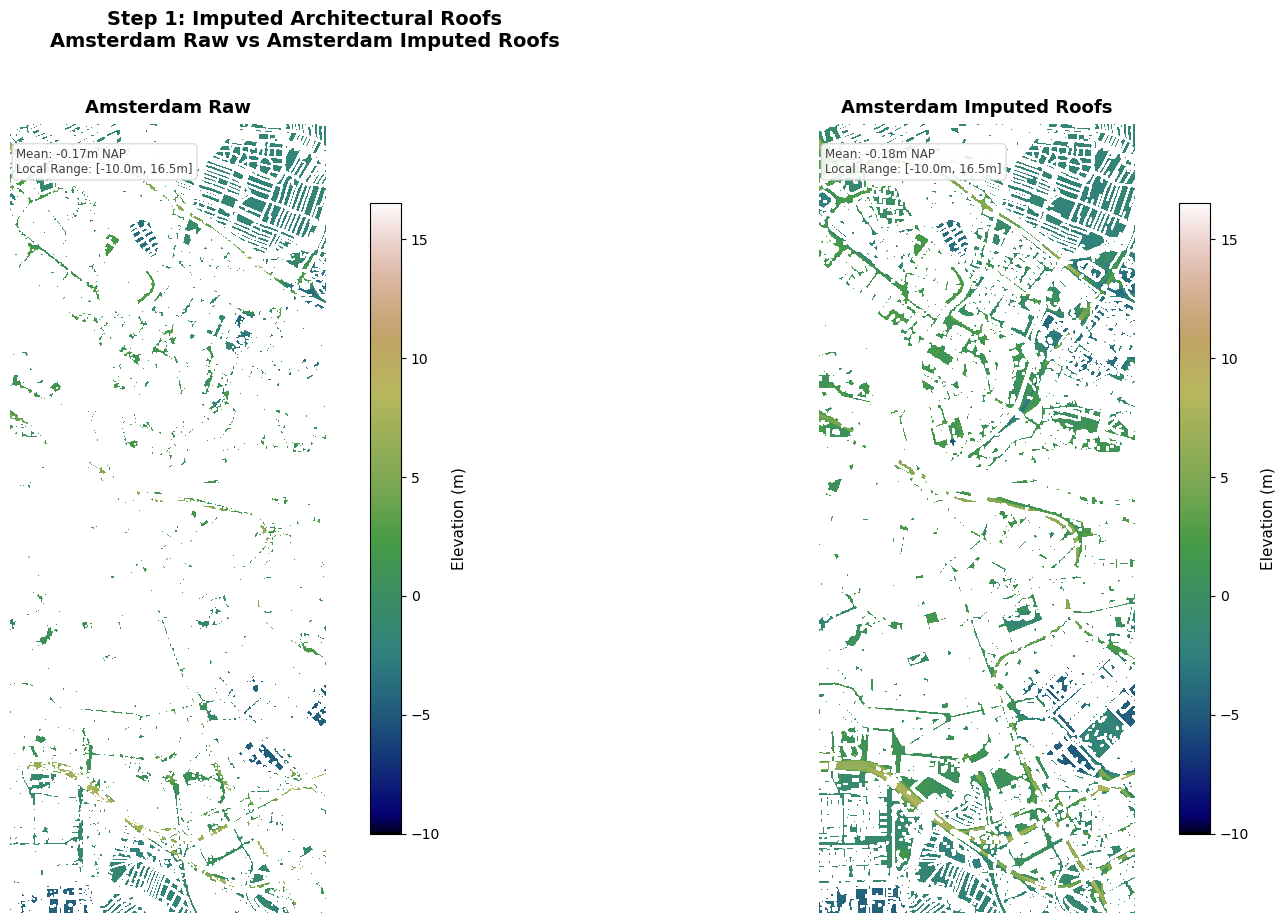

In [ ]:
step_1_dict = {
    "Amsterdam Raw": ams,
    "Amsterdam Imputed Roofs": ams_step1
}
plot_topological_grids(step_1_dict, step_title="Step 1: Imputed Architectural Roofs", cmap_name="gist_earth")

In [ ]:
cities = {"Amsterdam Step 1": ams_step1}
visualize_combined_missing_data(cities, ["Amsterdam Step 1"], output_path = "output/combined_missing_data_mask_step_1.png")


[SUCCESS] Saved unified column visualization to: output/combined_missing_data_mask.png



### Step 2: Extraction of Canal Boundary Skeleton
The remaining NaN regions were analyzed using binary dilation to detect land pixels directly bordering water gaps. A geodetic filter retained only low-elevation quay walls:

$$
\text{Valid Quay Walls} =
\text{Border Mask} \;\wedge\; (Z < -0.5\text{m NAP})
$$

**Topological goal:** isolate the structural canal boundaries without imputing data, creating stable guide rails for canal reconstruction.

---

In [ ]:
ams_step2 = ams_step1.copy()
remaining_nan_mask = np.isnan(ams_step2)

dilated_nan = ndimage.binary_dilation(remaining_nan_mask)
border_mask = dilated_nan & ~remaining_nan_mask

WALL_THRESHOLD = -0.5
valid_quay_walls = border_mask & (ams_step2 < WALL_THRESHOLD)

print(f"Step 2 Complete: Identified {np.sum(valid_quay_walls):,} structural quay wall border pixels.")

Step 2 Complete: Identified 2,220,487 structural quay wall border pixels.


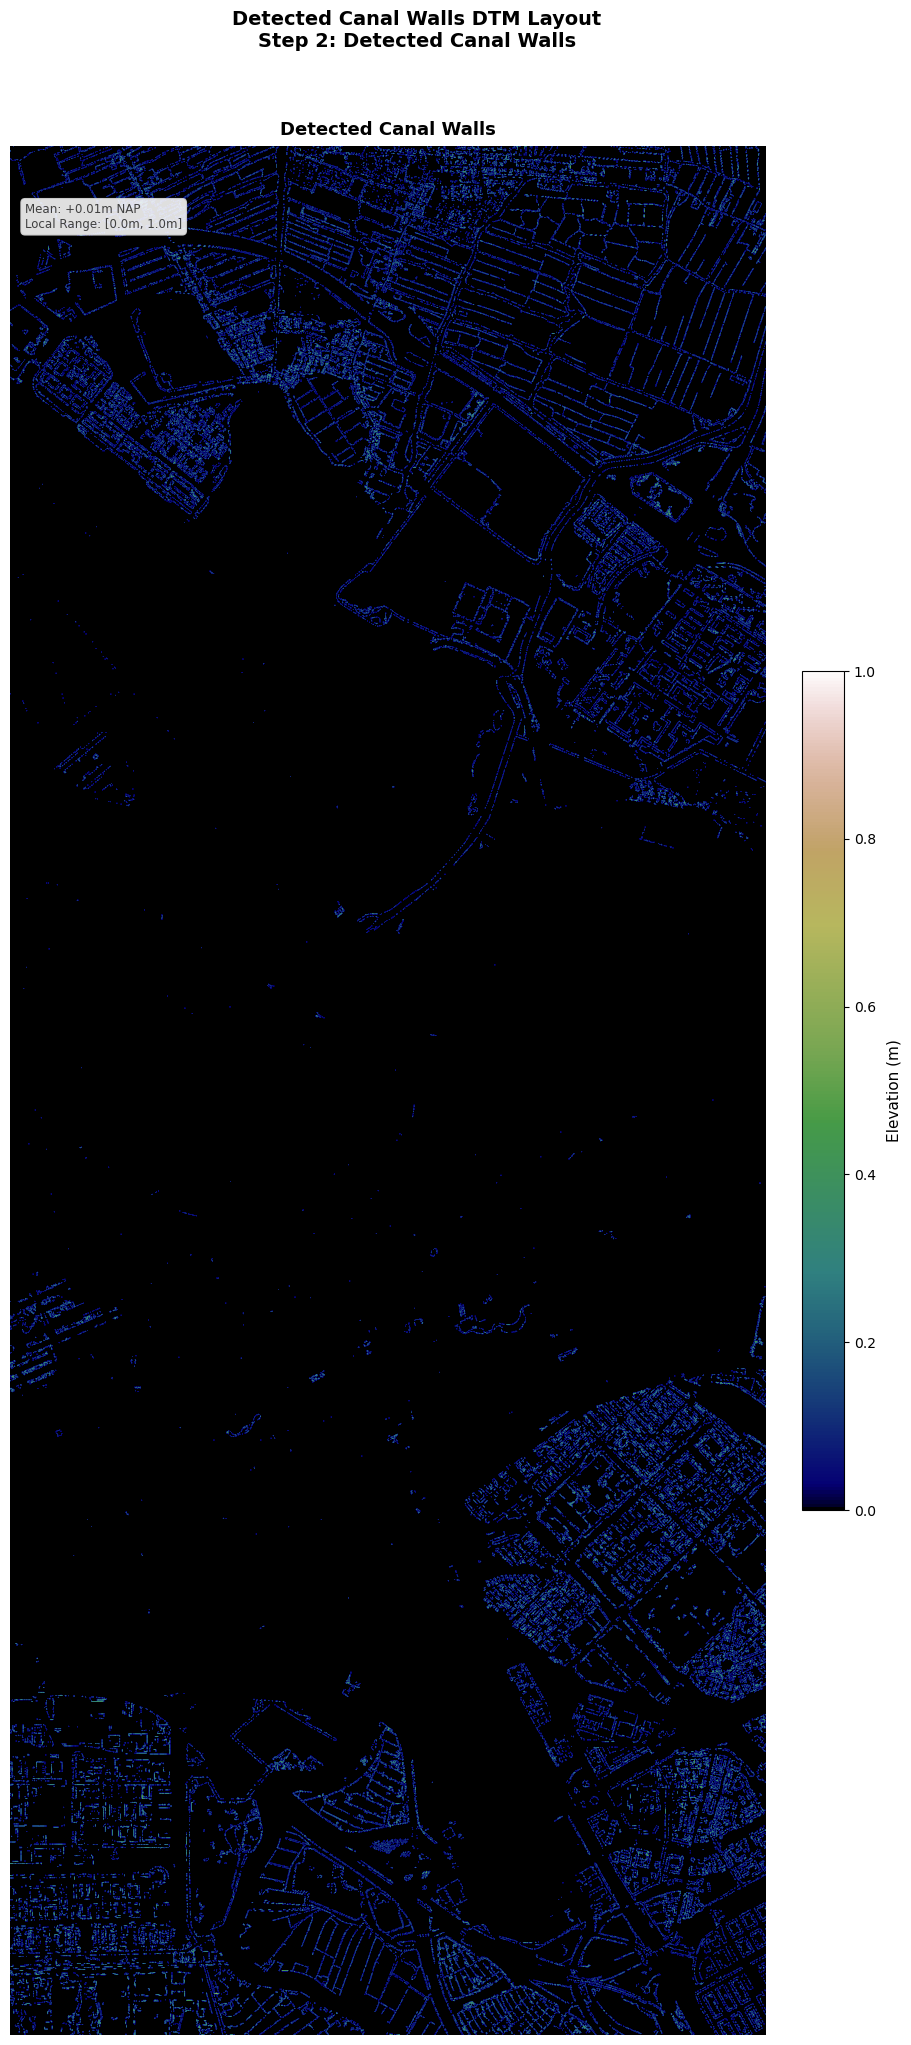

In [ ]:
step_2_dict = {
    "Detected Canal Walls": valid_quay_walls
}
plot_topological_grids(step_2_dict, step_title="Step 2: Detected Canal Walls", cmap_name="gist_earth")

### Step 3: Connected-Component Canal Imputation
Large water gaps were grouped into connected regions using 8-connectivity labeling (`ndimage.label`). Regions touching the quay-wall skeleton were identified as canals and assigned a uniform elevation of $-3.0\text{m}$ NAP.

**Topological goal:** preserve the global connectedness ($H_0$) of the canal network, ensuring the entire canal system appears simultaneously during sublevel filtration.

---

In [ ]:
ams_final = ams_step2.copy()
final_nan_mask = np.isnan(ams_final)

print("Grouping all remaining NaN voids into continuous segments...")
labeled_voids, num_voids = ndimage.label(final_nan_mask)

print("Finding which NaN segments touch the quay walls...")
dilated_walls = ndimage.binary_dilation(valid_quay_walls)
intersected_void_ids = unique_void_ids = np.unique(labeled_voids[dilated_walls])
intersected_void_ids = intersected_void_ids[intersected_void_ids != 0]

print("Flowing water through the connected canal network...")
connected_canal_mask = np.isin(labeled_voids, intersected_void_ids)

CANAL_DEPTH = -3.0
ams_final[connected_canal_mask] = CANAL_DEPTH

filled_count = np.sum(connected_canal_mask)
print(f"Step 3 Complete: Imputed {filled_count:,} water cells using topological connectivity.")

Grouping all remaining NaN voids into continuous segments...
Finding which NaN segments touch the quay walls...
Flowing water through the connected canal network...
Step 3 Complete: Imputed 60,946,421 water cells using topological connectivity.


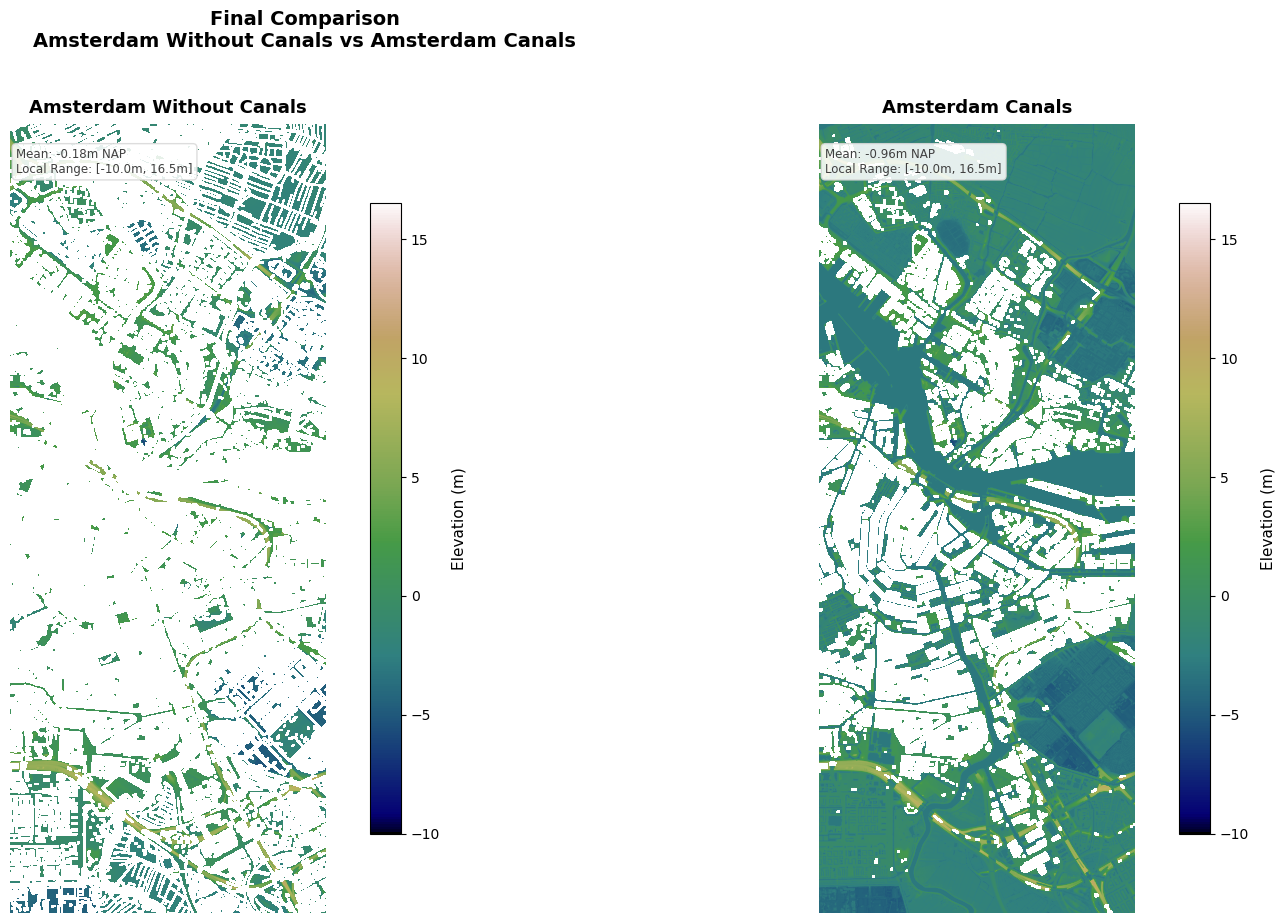

In [ ]:
step_3_dict = {
    "Amsterdam Without Canals": ams_step2,
    "Amsterdam Canals": ams_final
}
plot_topological_grids(step_3_dict, step_title="Final Comparison", cmap_name="gist_earth")

In [ ]:
cities = {"Amsterdam Step 3": ams_final}
visualize_combined_missing_data(cities, ["Amsterdam Step 3"], output_path = "output/combined_missing_data_mask_step_final.png")


[SUCCESS] Saved unified column visualization to: output/combined_missing_data_mask_step_final.png



### Step 4: Patch-Based IDW Land Reconstruction
Remaining dry-land gaps (mainly hollowed building footprints) were reconstructed using tiled Inverse Distance Weighting (IDW) with `cKDTree`. Only surrounding land points above canal level were used:

$$
\Omega_{\text{land}} =
\{x \mid Z(x)\neq \text{NaN} \;\wedge\; Z(x) > -2.99\text{m}\}
$$


**Topological goal**: smoothly restore urban terrain while preventing the $-3.0\text{m}$ canal elevations from propagating into land regions.

---

In [8]:
def global_patch_idw_imputation(elev_matrix, min_land_elevation=-2.99, search_radius=15, tile_size=1000):
    output_matrix = elev_matrix.copy()
    H, W = output_matrix.shape
    
    # Calculate padding offset so tiles can look across boundaries for edge calculations
    pad = search_radius + 5  
    
    # Generate tile coordinates across the master grid dimensions
    row_steps = range(0, H, tile_size)
    col_steps = range(0, W, tile_size)
    total_tiles = len(row_steps) * len(col_steps)
    
    print(f"Global Grid Split into {total_tiles} low-memory compute tiles ({tile_size}x{tile_size}).")
    tile_idx = 0
    
    for r_start in row_steps:
        for c_start in col_steps:
            tile_idx += 1
            
            # 1. Map target window coordinates with cushion padding limits
            r_end = min(r_start + tile_size, H)
            c_end = min(c_start + tile_size, W)
            
            r_start_pad = max(0, r_start - pad)
            r_end_pad = min(H, r_end + pad)
            c_start_pad = max(0, c_start - pad)
            c_end_pad = min(W, c_end + pad)
            
            # Quick check: If there are no missing data gaps inside the core tile area, 
            # skip it entirely to save significant calculation time
            local_nans_in_core = np.isnan(output_matrix[r_start:r_end, c_start:c_end])
            if not np.any(local_nans_in_core):
                continue
                
            # 2. Extract local buffered tile matrix
            patch = output_matrix[r_start_pad:r_end_pad, c_start_pad:c_end_pad]
            patch_nan = np.isnan(patch)
            
            # 3. Filter references to extract ONLY the valid terrain targets above threshold
            valid_land = (~patch_nan) & (patch > min_land_elevation)
            if not np.any(valid_land):
                continue  # Skip if the current sector is entirely missing data voids
                
            # 4. Generate a highly constrained, memory-safe KDTree index for the patch
            l_rows, l_cols = np.where(valid_land)
            l_elevs = patch[valid_land]
            land_coords = np.column_stack((l_rows, l_cols))
            spatial_tree = cKDTree(land_coords)
            
            # 5. Execute localized pixel-by-pixel IDW within the core patch boundary limits
            # This loop maps local coordinates back onto the true master grid frame indices
            for local_r in range(r_start - r_start_pad, (r_end - r_start_pad)):
                for local_c in range(c_start - c_start_pad, (c_end - c_start_pad)):
                    
                    if patch_nan[local_r, local_c]:
                        # Query the localized KDTree within the ground radius range
                        neighbor_indices = spatial_tree.query_ball_point([local_r, local_c], r=search_radius)
                        
                        global_r = r_start_pad + local_r
                        global_c = c_start_pad + local_c
                        
                        if len(neighbor_indices) > 0:
                            coords = land_coords[neighbor_indices]
                            elevs = l_elevs[neighbor_indices]
                            
                            # Calculate exact Euclidean distance profile to neighbors
                            distances = np.sqrt((coords[:, 0] - local_r)**2 + (coords[:, 1] - local_c)**2)
                            distances = np.maximum(distances, 0.1)  # Safeguard against division by 0
                            
                            # Inverse Square Distance formulation: Weight = 1 / d^2
                            weights = 1.0 / (distances ** 2)
                            
                            # Assign the continuous weighted average back into the master grid layout
                            output_matrix[global_r, global_c] = np.sum(elevs * weights) / np.sum(weights)
                        else:
                            # Robust Fallback: If a hole is too wide to find neighbors within radius,
                            # find the single closest valid pixel regardless of distance limit constraints
                            _, closest_idx = spatial_tree.query([local_r, local_c], k=1)
                            output_matrix[global_r, global_c] = l_elevs[closest_idx]
                            
            # Output routine diagnostic logging interval checks
            if tile_idx % 20 == 0 or tile_idx == total_tiles:
                print(f"Progress: Processed {tile_idx}/{total_tiles} tiles successfully...")
                
    return output_matrix

In [ ]:
# Run the memory-safe global tile imputation
# By checking values > -2.99, we use all valid terrain data while protecting the canal beds
ams_final_remaining = global_patch_idw_imputation(
    ams_final, 
    min_land_elevation=-2.99,  # Slices cleanly above the -3.0m canal beds
    search_radius=15,
    tile_size=1000
)

print(f"Global Imputation Complete!")
print(f"Total remaining NaNs in your global dataset: {np.sum(np.isnan(ams_final_remaining))}")
np.save("output/ams_final_imputed.npy", ams_final_remaining)

Global Grid Split into 250 low-memory compute tiles (1000x1000).
Progress: Processed 80/250 tiles successfully...
Progress: Processed 100/250 tiles successfully...
Progress: Processed 120/250 tiles successfully...
Progress: Processed 140/250 tiles successfully...
Progress: Processed 160/250 tiles successfully...
Progress: Processed 180/250 tiles successfully...
Progress: Processed 220/250 tiles successfully...
Progress: Processed 240/250 tiles successfully...
Progress: Processed 250/250 tiles successfully...
Global Imputation Complete!
Total remaining NaNs in your global dataset: 0


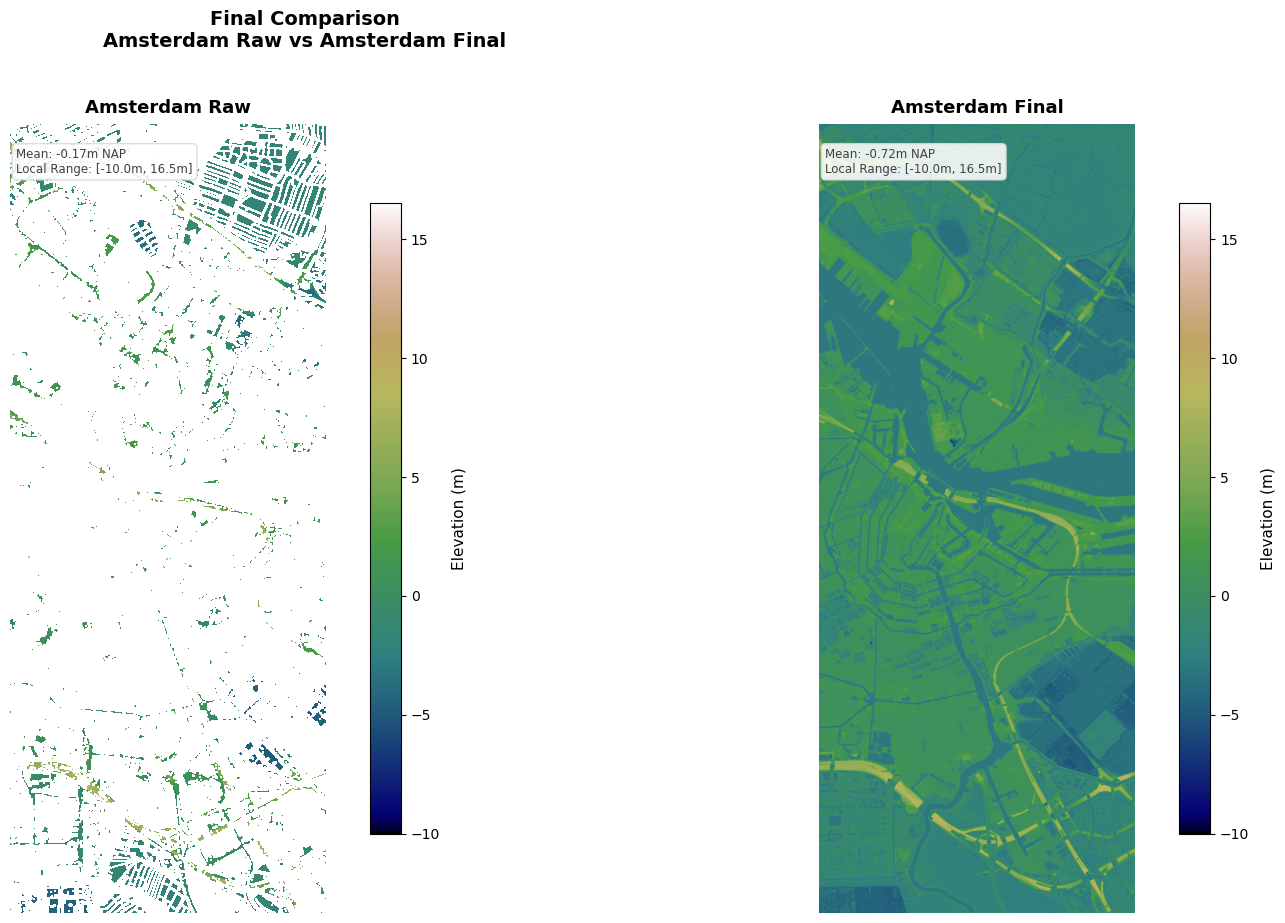

In [ ]:
step_3_dict = {
    "Amsterdam Raw": ams,
    "Amsterdam Final": ams_final_remaining
}
plot_topological_grids(step_3_dict, step_title="Final Comparison", cmap_name="gist_earth")

## Data Imputation Eindhoven

## Missing Data Observations — Eindhoven

- Almost 25% missing data
- Missing regions are primarily buildings and urban areas

## Imputation Plan

### Step 1 — Micro-Inpainting
Fills small sparse holes across roofs and terrain using local interpolation, reducing early topological noise.

### Step 2 — Canal Flood-Fill
Uses connected-component propagation to fill only contiguous canal regions, fixing canal elevations at a geodetically accurate level of $10.5\,\mathrm{m}$ NAP.

### Step 3 — Patch-Based IDW
Interpolates remaining large building-footprint gaps in memory-safe $1000 \times 1000$ tiles using only land elevations, preventing canals from bleeding into street terrain.

In [3]:
# Initialize our working matrix from your loaded 'ams' data
ehv_step1 = ehv.copy()
nan_mask = np.isnan(ehv_step1)

# 1. Isolate the small architectural roof gaps by labeling all NaN components
labeled_masks, num_features = ndimage.label(nan_mask)
feature_sizes = ndimage.sum(nan_mask, labeled_masks, range(1, num_features + 1))

# Define roof holes as anything smaller than 500 pixels (massive holes are canals)
HOLE_THRESHOLD = 500
small_hole_indices = np.where(feature_sizes <= HOLE_THRESHOLD)[0] + 1
roof_gaps_mask = np.isin(labeled_masks, small_hole_indices)

# 2. Localized spatial interpolation to patch the roof gaps
indices = ndimage.distance_transform_edt(
    nan_mask, 
    return_distances=False, 
    return_indices=True
)
interpolated_full = ehv_step1[tuple(indices)]

# Impute ONLY the roof gaps, leaving large canal voids untouched
ehv_step1[roof_gaps_mask] = interpolated_full[roof_gaps_mask]
print(f"Step 1 Complete: Imputed {np.sum(roof_gaps_mask):,} architectural roof pixels.")

Step 1 Complete: Imputed 9,878,064 architectural roof pixels.


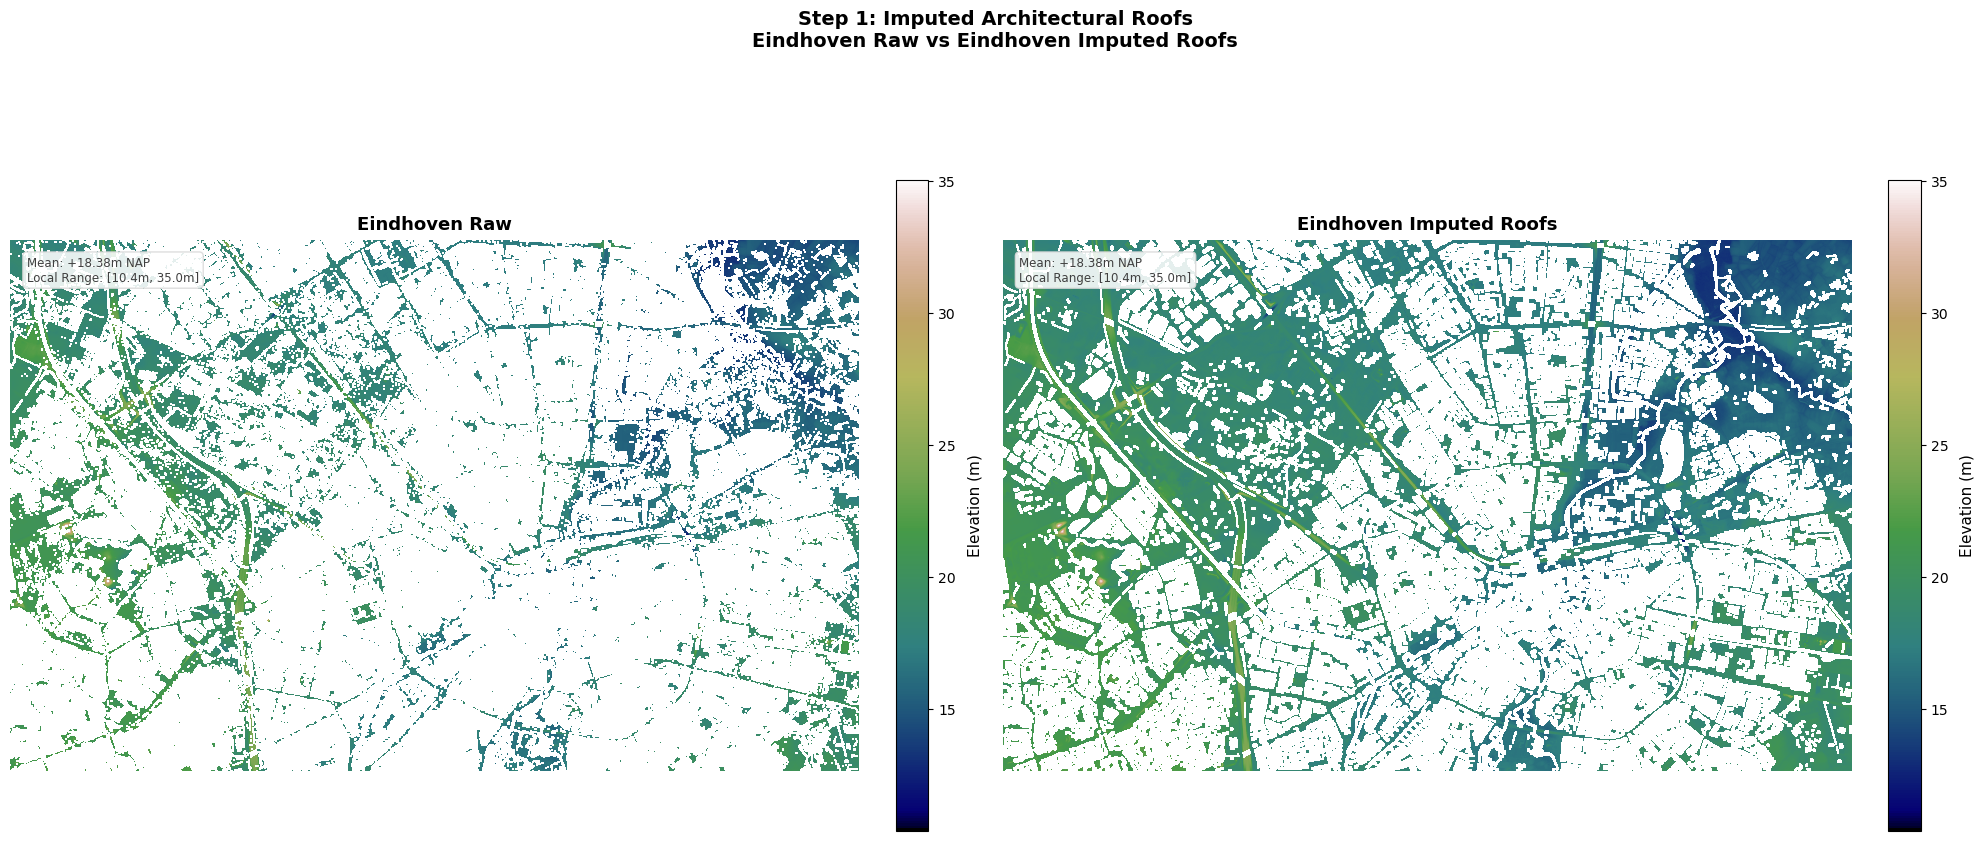

In [4]:
step_1_dict = {
    "Eindhoven Raw": ehv,
    "Eindhoven Imputed Roofs": ehv_step1
}
plot_topological_grids(step_1_dict, step_title="Step 1: Imputed Architectural Roofs", cmap_name="gist_earth")

--- Visualizing Binary Gaps (Red = Missing) ---

[SUCCESS] Saved unified column visualization to: output/combined_missing_data_mask.png



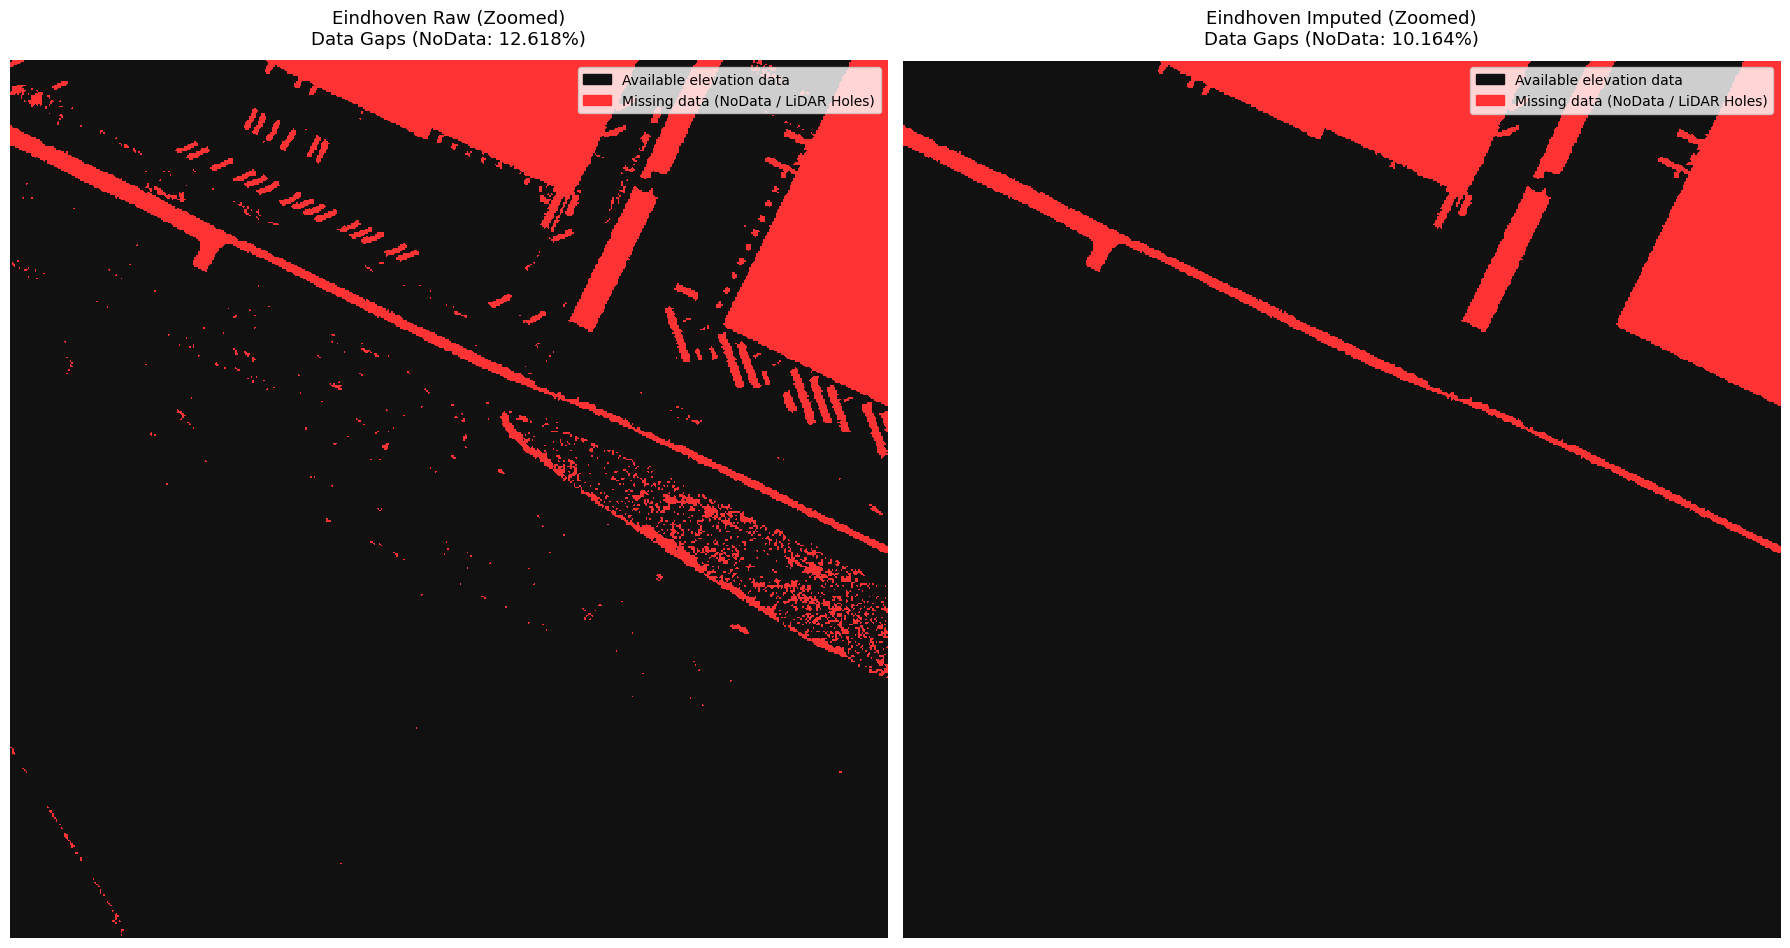

--- Visualizing Elevation Changes ---


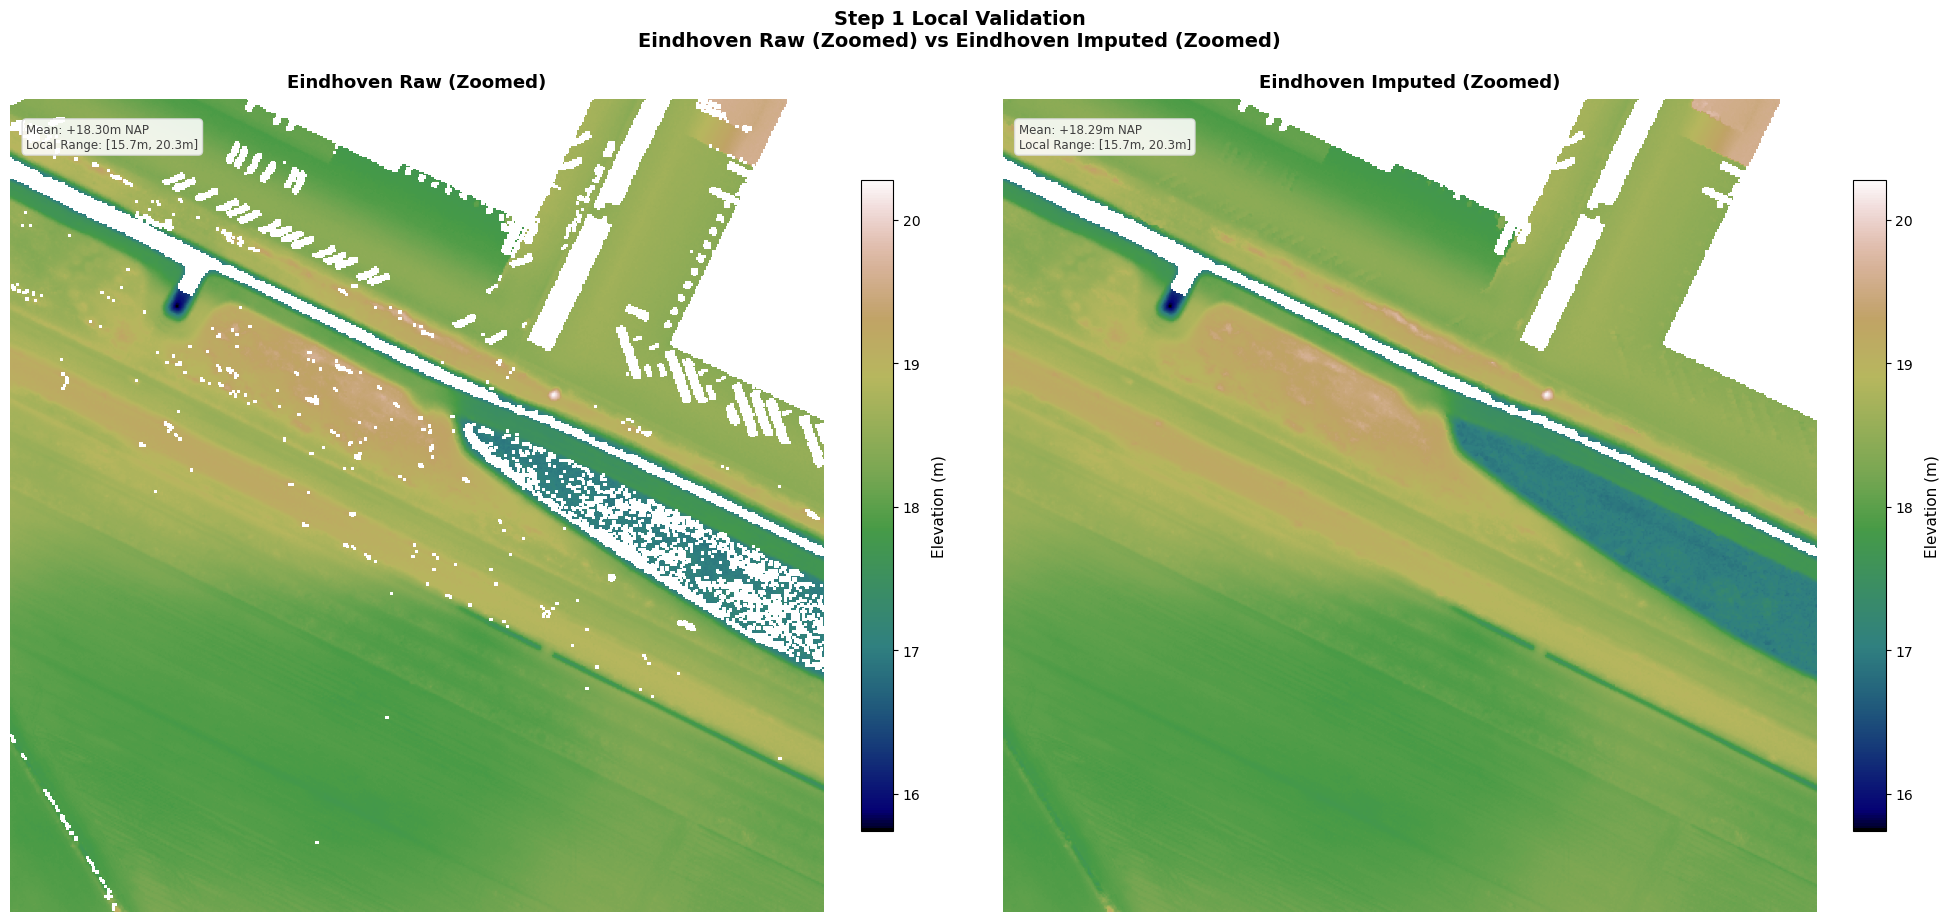

In [5]:
# 1. Define a local bounding box coordinates where small gaps exist
# (Adjust rows 2000:2500 and cols 3000:3500 if you want to target a specific neighborhood)
row_start, row_end = 2000, 2500
col_start, col_end = 3000, 3500

# 2. Extract identical windows from the raw data and your processed step 1 data
raw_patch    = ehv[row_start:row_end, col_start:col_end]
imputed_patch = ehv_step1[row_start:row_end, col_start:col_end]

# 3. Package them for comparison
step_1_local_dict = {
    "Eindhoven Raw (Zoomed)": raw_patch,
    "Eindhoven Imputed (Zoomed)": imputed_patch
}

# 4. Run the binary mask plot on the local patches
print("--- Visualizing Binary Gaps (Red = Missing) ---")
plot_data_binary(step_1_local_dict, list(step_1_local_dict.keys()))

# 5. Run the elevation map plot on the local patches
print("--- Visualizing Elevation Changes ---")
plot_topological_grids(step_1_local_dict, step_title="Step 1 Local Validation", cmap_name="gist_earth")

## Step 2 — Topological Waterbody Detection and Flood-Fill
Filters in this code were set by hand after multiple tests. It needs further optimization or change of the method. Can be used as a baseline for future work.

This stage identifies true hydrological structures within the remaining missing-data regions and reconstructs them using a controlled flood-fill elevation model.

### Objective
Detect rivers, canals, and organically shaped water bodies while rejecting geometric acquisition artifacts such as scanner strips, rectangular voids, and flight-edge gaps.

---

## Processing Pipeline

### 1. Missing Region Segmentation
The algorithm begins by copying the partially repaired elevation grid from Step 1 and generating a binary mask of all remaining missing values (`NaN`).

Connected-component labeling is then applied using:

```python
labeled_voids, num_features = ndimage.label(nan_mask)


Topological Hull Analysis Complete.
Retained true rivers and curvy lakes. Purged geometric scanner artifacts.
Successfully flooded channels and lakes to 10.5m NAP.


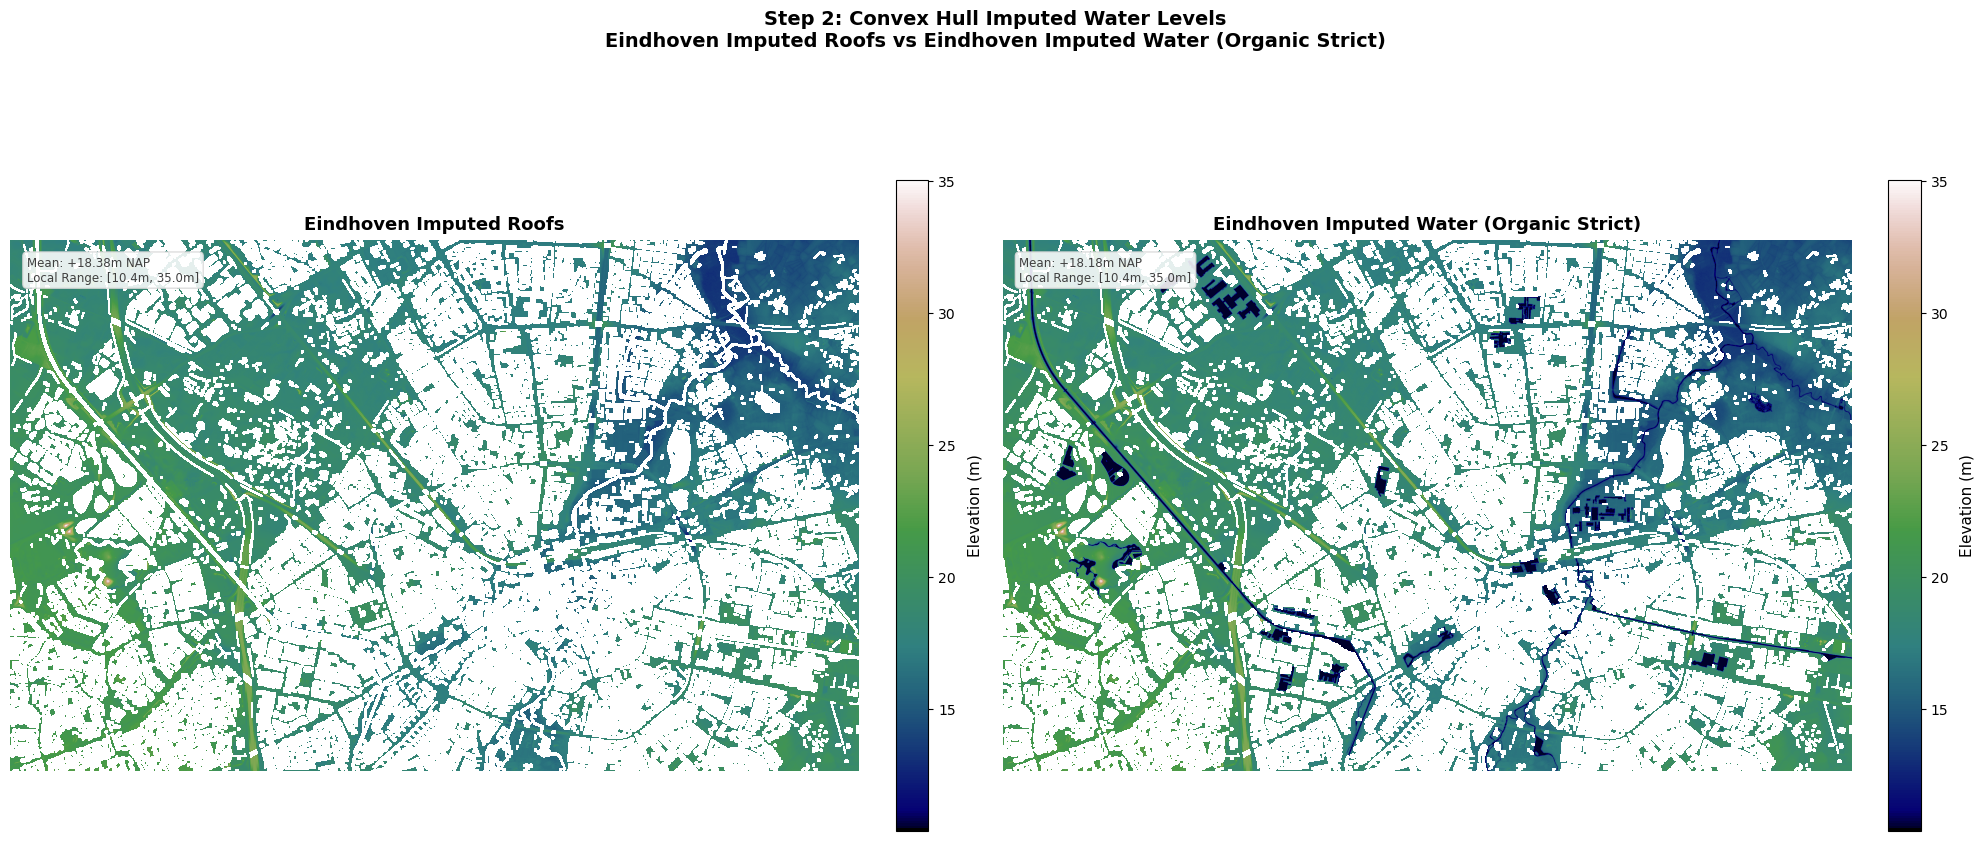

In [ ]:
# Initialize clean matrices from step 1 data
ehv_step2 = ehv_step1.copy()
nan_mask = np.isnan(ehv_step2)

# 1. Label all missing data regions into separate connected structures
labeled_voids, num_features = ndimage.label(nan_mask)

# 2. Extract detailed topological and geometric regions using skimage
# regionprops automatically calculates areas, bounding boxes, and convex hulls
regions = regionprops(labeled_voids)

# Master list to collect the component IDs of valid water features
valid_water_indices = []

for prop in regions:
    feature_id = prop.label
    pixel_area = prop.area
    
    # Keeping your highly optimized baseline size threshold
    if pixel_area > 100000:
        
        # Extract advanced structural metrics
        compactness_ratio = pixel_area / prop.bbox_area
        max_span = max(prop.image.shape)
        
        # SOLIDITY: Measures how organic/curvy vs straight/geometric a shape is.
        # Perfectly flat scanner strips or corner triangles will have a solidity ~ 1.0
        solidity = prop.solidity 
        
        # --- LOGICAL CLASSIFICATION CHANNEL ---
        # Rule A (Rivers): Long, meandering, narrow paths
        is_river = (max_span > 600) and (compactness_ratio < 0.20)
        
        # Rule B (Organic Lakes & Curvy Basins): 
        # Massive voids that are naturally shaped (solidity < 0.82 ensures perfectly 
        # straight edge lines, scanner rectangles, and sharp flight triangles are rejected)
        is_organic_water = (pixel_area > 100000) and (solidity < 0.82)
        
        if is_river or is_organic_water:
            valid_water_indices.append(feature_id)

# 3. Compile the definitive water mask containing only verified rivers and lakes
detected_water_mask = np.isin(labeled_voids, valid_water_indices)

# 4. Extract the Quay Walls strictly tracking the edge of valid water bodies
dilated_water = ndimage.binary_dilation(detected_water_mask)
valid_quay_walls = dilated_water & ~nan_mask

print(f"Topological Hull Analysis Complete.")
print(f"Retained true rivers and curvy lakes. Purged geometric scanner artifacts.")

# 5. FLOOD-FILL: Assign a uniform water elevation matching Eindhoven's valley floors
EHV_WATER_LEVEL = 10.5  
ehv_step2[detected_water_mask] = EHV_WATER_LEVEL
print(f"Successfully flooded channels and lakes to {EHV_WATER_LEVEL}m NAP.")

# 6. Render using your topological grids comparison tool
step_2_dict = {
    "Eindhoven Imputed Roofs": ehv_step1,
    "Eindhoven Imputed Water (Organic Strict)": ehv_step2
}
plot_topological_grids(step_2_dict, step_title="Step 2: Convex Hull Imputed Water Levels", cmap_name="gist_earth")

## Some data is incorrectly imputed
Rivers and lakes dicovered correctly but buildings and boxes shapes are misclassified as water

In [9]:
ehv_final_imputed = global_patch_idw_imputation(
    ehv_step2, 
    min_land_elevation=10.6,   # Slices cleanly above the 10.5m water bodies
    search_radius=30,          # Expanded radius to smoothly bridge larger industrial/factory footprints
    tile_size=1000             # Keeps memory footprints safe for the 12500x20000 grid
)

print(f"Global Imputation Complete!")
print(f"Remaining NaNs in Eindhoven dataset: {np.sum(np.isnan(ehv_final_imputed))}")

# Save your final imputed terrain artifact
np.save("output/ehv_final_imputed.npy", ehv_final_imputed)

Global Grid Split into 260 low-memory compute tiles (1000x1000).
Progress: Processed 20/260 tiles successfully...
Progress: Processed 40/260 tiles successfully...
Progress: Processed 60/260 tiles successfully...
Progress: Processed 80/260 tiles successfully...
Progress: Processed 100/260 tiles successfully...
Progress: Processed 120/260 tiles successfully...
Progress: Processed 140/260 tiles successfully...
Progress: Processed 160/260 tiles successfully...


KeyboardInterrupt: 